In [39]:
import numpy as np
from math import *
from scipy.optimize import minimize
from scipy.optimize import fmin_bfgs
import scipy.optimize as opt
import numpy as np
from math import *
from itertools import *
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import time
# from joblib import Parallel, delayed
# from scipy.optimize import minimize
# import joblib
from matplotlib import ticker


np.set_printoptions(suppress=True)
## Parallelization
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from scipy.optimize import minimize
import joblib

joblib.cpu_count()



import os

def create_subfolders(parent_directory, subfolder_names, nested_subfolder_names):
    for folder_name in subfolder_names:
        # Construct the full path for the new subfolder
        subfolder_path = os.path.join(parent_directory, folder_name)
        try:
            # Create the main subfolder
            os.makedirs(subfolder_path)
            print(f"Created subfolder: {subfolder_path}")

            # Create nested subfolders
            for nested_folder_name in nested_subfolder_names:
                nested_subfolder_path = os.path.join(subfolder_path, nested_folder_name)
                os.makedirs(nested_subfolder_path)
                print(f"Created nested subfolder: {nested_subfolder_path}")
        except OSError as error:
            print(f"Error creating subfolder {subfolder_path}: {error}")

# # Define the parent directory
# parent_directory = "solns_runs/Ex4"

# # Generate main subfolder names T1, T2, ..., T50
# subfolder_names = [f"T{i}" for i in range(1, 51)]

# # Generate nested subfolder names N100, N200, ..., N1500
# nested_subfolder_names = [f"N{i}" for i in range(100, 1501, 100)]

# # Create the subfolders
# create_subfolders(parent_directory, subfolder_names, nested_subfolder_names)


def F(x, lam):
    x1, x2 = x
    return np.array([
        2*x1 + 8/3*x2 - 34 + lam,
        2*x2 + 5/4*x1 - 24.25 + lam
    ])


def proj_X_opt(x):
    """
    Project point x = (x1, x2) onto
    X = { (u,v) | u >= 0, v >= 0, u+v <= 1 }
    """
    x = np.asarray(x)

    # Objective: minimize squared distance
    def objective(u):
        return 0.5 * np.sum((u - x)**2)

    # Constraints
    constraints = [
        {"type": "ineq", "fun": lambda u: u[0]},          # u >= 0
        {"type": "ineq", "fun": lambda u: u[1]},          # v >= 0
        {"type": "ineq", "fun": lambda u: 15 - u[0] - u[1]} # u+v <= 15
    ]

    # Initial guess
    z0 = np.maximum(x, 0)  # clip negative values to start inside nonnegative orthant
    bounds = [(0, 10), (0, 10)]

    result = minimize(objective, z0, constraints=constraints, bounds= bounds)

    return result.x


def const(x):
    return 15-(x[0]+x[1])

# ------------------- Dummy Lambda function -------------------
def Lambda_of_x(x):
    return [(np.array([1.0]), np.array([0.0]))]

# ------------------- Projected gradient VI solver -------------------
n_runs= 3
def vi_solver(l, step=0.001, max_iter=1000, tol=1e-8):
    x0= np.random.uniform(0, 10, size=2)
    x = x0.copy()
    for _ in range(max_iter):
        x_new = proj_X_opt(x - step * F(x, l))
        if np.linalg.norm(x_new - x) < tol:
            return x_new
        x = x_new
    if np.abs(const(x_new)*l)< 1e-6:
        return x_new
    else:
        return None

# def vi_solver(l, step=0.001, max_iter=1000, tol=1e-8):
#     x0= np.random.uniform(0, 10, size=2)
#     x = x0.copy()
#     res= []
#     for _ in range(n_runs):
#         for _ in range(max_iter):
#             x_new = proj_X_opt(x - step * F(x, l))
#             if np.linalg.norm(x_new - x) < tol:
#                 res.append(x_new)
# #                 return x_new
#             x = x_new
#         if np.linalg.norm(const(x)*l)<= 1e-6:
#             res.append(x)
# #             return x
#     if len(res) != 0:
#         return res
#     else:
#         return None
def organize_solutions(solns):
    set_of_points= []
    for sol in solns:
        if sol is not None:
            set_of_points.append(list(sol))

    return set_of_points

def discretize_time_interval(T,num_points):
    """
    Discretize the time interval [0, T] with a given time step (delta_t).

    Parameters:
    - T: Total time duration
    - delta_t: Time step size

    Returns:
    - time_points: List of discretized time points
    """
    start = 0#T-1

    # Calculate the width of each sub-interval
    interval_width = (T - start) / (num_points - 1)

    # Generate the points
    points = [start + i * interval_width for i in range(num_points)]

    return points

number_points_list= [100, 200,300,400,500,600,700,800,900,1000,1100,1200, 1300,1400,1500]
#number_points_list= [10, 20]
#n_runs= [5, 10, 15, 20, 25, 30, 35, 40, 50, 55, 60]
#number_points_list= [100, 200]
T_list= [T for T in range(1,2)]
# n_runs= [10]

def run_for_lam(lmb):
    results = Parallel(n_jobs=-1)(delayed(vi_solver)(lam) for lam in lmb)
    set_of_points= organize_solutions(results)
    return set_of_points
def run_n(lmb, n_r= 10):
    results = Parallel(n_jobs=8)(delayed(run_for_lam)(lmb) for _ in range(n_r))
    set_of_points= organize_solutions(results)
    res= []
    for i in set_of_points:
        res.extend(i)
    return np.array(res)
def run_(lambd):
    results = Parallel(n_jobs=-1)(delayed(run_for_lam)(lam) for lam in lambd)
    set_of_points= organize_solutions(results)
    return set_of_points
def run_for_lam_run(lmb,n_runs):
    results = Parallel(n_jobs=-1)(delayed(run_)(lmb) for _ in range(n_runs))
#     results = Parallel(n_jobs=-1)(delayed(run_for_lam)(lmb) for _ in range(n_runs))
    set_of_points= organize_solutions(results)
    return set_of_points


# def run_for_different_runs(T,n_r= 10):
#     lambd = Parallel(n_jobs=2)(delayed(discretize_time_interval)(T, num_points) for num_points in number_points_list)
#     result= run_for_lam_run(lambd,n_r)
   
#     for idx_run in range(n_r):
#         results= result[idx_run]
# # #         results = Parallel(n_jobs=-1)(delayed(run_for_lam)(lam) for lam in lambd)
#         for n_points in range(len(results)):
#             np.savetxt('./solns_runs/Ex4/T'+str(T)+'/'+'N'+str(number_points_list[n_points])+"/"+str(idx_run+1)+"_"+"solns"+'_'+'run'+str(n_r)+'_'+str(number_points_list[n_points])+'pts'+'.txt', np.array(results[n_points]), delimiter=',')




In [40]:
T= 4
lambd = Parallel(n_jobs=2)(delayed(discretize_time_interval)(T, num_points) for num_points in number_points_list)


In [41]:
# len(lambd)
vi_solver(0.0)

array([8.53180808, 6.46819192])

In [4]:
# tt= run_for_lam(lambd[0])

In [ ]:
# tt

In [ ]:
# plt.scatter(np.array(tt)[:,0], np.array(tt)[:,1], c= 'black')
# plt.xlim([0,10])
# plt.ylim([0,10])
# plt.grid(True)
# plt.show()

In [103]:
# results = Parallel(n_jobs=2)(delayed(run_for_lam)(lam) for lam in lambd)

In [ ]:
# vi_solver(l= 0.0, step=0.001, max_iter=2000, tol=1e-8)

In [ ]:
# data= []

In [ ]:
# for l in range(len(lambd)):
#     print(l)
#     res= run_for_lam(lambd[l])
#     data.append(res)

In [ ]:
# data

In [ ]:
# all_data= dict.fromkeys(range(len(data)), 0)

# for i in range(len(data)):
#     all_data[i]= data[i]

# import json
# with open("Ex4PVI.json", "w") as f:
#     json.dump(all_data, f)

In [ ]:
# Filter solutions

In [6]:
# T= 5
# n_runs= 3

In [7]:
# All T

In [8]:
def runT(T):
    lambd = Parallel(n_jobs=6)(delayed(discretize_time_interval)(T, num_points) for num_points in number_points_list)
    data= []
    for l in range(len(lambd)):
        res= run_n(lambd[l])
        data.append(res)
    return data

In [9]:
T_list= [1, 2, 3, 4, 5]

T_data= dict.fromkeys(range(1, len(T_list)+1), 0)

T_data

{1: 0, 2: 0, 3: 0, 4: 0, 5: 0}

In [10]:
for T in T_list:
    print("Running for T= ", T)
    res= runT(T)
    T_data[T]= res
    print(len(res))

Running for T=  1
15
Running for T=  2
15
Running for T=  3
15
Running for T=  4
15
Running for T=  5
15


In [11]:
T

5

In [14]:
# import json
# with open("Ex2PVIT.json", "w") as f:
#     json.dump(T_data, f)

import json
import numpy as np

def convert(obj):
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, np.floating):
        return float(obj)
    raise TypeError(f"Type {type(obj)} not serializable")

with open("Ex4PVIT.json", "w") as f:
    json.dump(T_data, f, default=convert)

In [13]:
# import json
# with open("Ex4PVIT.json", "w") as f:
#     json.dump(T_data, f)

In [15]:
T_data[3]

[array([[8.00565951, 6.93778325],
        [9.00569821, 5.99430179],
        [9.99333489, 5.00666511],
        [9.84394113, 5.15605887],
        [9.86453965, 5.13546035],
        [9.88281328, 5.11718672],
        [8.52556268, 6.47443732],
        [9.73939355, 5.26060645],
        [9.91492166, 5.08507834],
        [9.65633821, 5.34366179],
        [9.92210772, 5.07789228],
        [8.80985723, 6.19014277],
        [9.61503177, 5.38496823],
        [9.13175349, 5.86824651],
        [9.9931764 , 5.0068236 ],
        [8.86697148, 6.13302852],
        [9.84225326, 5.15774674],
        [9.22663419, 5.77336581],
        [9.59227426, 5.40772574],
        [8.69903678, 6.30096322],
        [9.07277592, 5.92722408],
        [9.4413056 , 5.5586944 ],
        [9.03175939, 5.96824061],
        [9.95638078, 5.04361922],
        [9.62236473, 5.37763527],
        [6.61586045, 7.80387885],
        [9.83636845, 5.16363155],
        [9.95328902, 5.04671098],
        [9.83030644, 5.16969356],
        [9.800

In [16]:
res

[array([[9.69699732, 5.30300268],
        [9.90824013, 5.09175987],
        [9.96678496, 5.03321504],
        [9.95948534, 5.04051466],
        [9.83585658, 5.16414342],
        [6.22475606, 8.17105499],
        [9.98538293, 5.01461707],
        [9.96014105, 5.03985895],
        [9.4123526 , 5.5876474 ],
        [8.11910143, 6.62191934],
        [9.92778096, 5.07221904],
        [9.93569988, 5.06430012],
        [6.21659731, 8.01309836],
        [9.74586777, 5.25413223],
        [9.97558018, 5.02441982],
        [9.86951785, 5.13048215],
        [9.74629466, 5.25370534],
        [9.88141632, 5.11858368],
        [9.76340285, 5.23659715],
        [9.88550888, 5.11449112],
        [9.73915707, 5.26084293],
        [5.25893075, 8.8387428 ],
        [9.43973089, 5.56026911],
        [9.14319437, 5.85680563],
        [9.90232508, 5.09767492],
        [9.92003718, 5.07996282],
        [9.43255419, 5.56744581],
        [6.04125261, 8.11596402],
        [9.20266659, 5.79733341],
        [9.491

# Track $T_{max}$

In [9]:
import json
import numpy as np

import numpy as np
from math import *
from scipy.optimize import minimize
from scipy.optimize import fmin_bfgs
import scipy.optimize as opt
import numpy as np
from math import *
from itertools import *
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import time
# from joblib import Parallel, delayed
# from scipy.optimize import minimize
# import joblib
from matplotlib import ticker


np.set_printoptions(suppress=True)
## Parallelization
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from scipy.optimize import minimize
import joblib

joblib.cpu_count()

number_points_list= [100, 200,300,400,500,600,700,800,900,1000,1100,1200, 1300,1400,1500]


import json

In [10]:
def const(x):
    return 15-(x[0]+x[1])

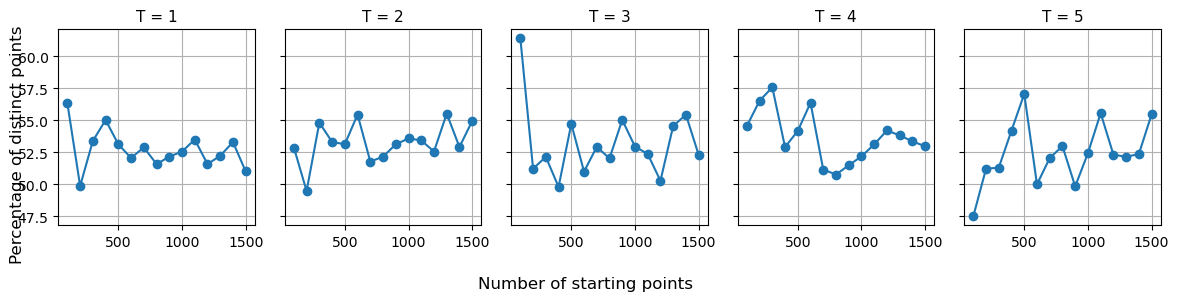

In [13]:
with open('./Ex4PVIT.json') as f:
    dataT= json.load(f)
    
    
T_list= [1, 2, 3, 4, 5] # T= 1 is the one giving meaningfull solution[1, 2, 3, 4, 5]
data_dict= dict.fromkeys(range(1, len(T_list)+1), 0)




for T in T_list:
    data_all= []

    for i in range(len(number_points_list)):
        res_= []
        # print(dataT[str(T)][i])

        if len(dataT[str(T)][i])== 0:
            # print(dataT[str(1)][i])
            data_all.append([dataT[str(T)][i]])
            # res_.append([dataT[str(1)][i]])
        else:
            # print(data[str(i)])
            for t in range(len(dataT[str(T)][i])):
                # print(data[str(i)][t])
                if np.abs(const(dataT[str(T)][i][t]))<= 1e-6:
                    res_.append(dataT[str(T)][i][t])
            data_all.append(res_)
    data_dict[T]= data_all
    
    
res_all= []

for i in range(len(number_points_list)):
    res= []
    for T in T_list:
        res.extend(data_dict[T][i])

    res_all.append(res)
    
data_all= res_all


dt_res= []

for i in range(len(number_points_list)):
    cleaned_data = [x for x in data_all[i] if x != []]
    # print(cleaned_data)
    dt_res.append(cleaned_data)
    # break

data_all= dt_res


import numpy as np

def calculate_distance(point1, point2):
    return sum((x - y) ** 2 for x, y in zip(point1, point2)) ** 0.5

def calculate_tolerance(points):
    num_points = len(points)
    tolerance = 1/num_points
    return tolerance
    
def count_repeated_points(points):
    #points = points[np.lexsort((points[:, 1], points[:, 0]))]
    #n= len(points)
    ep=  calculate_tolerance(points)
    distinct_points = []

    for point in points:
        is_distinct = True
        for distinct_point in distinct_points:
            if calculate_distance(point, distinct_point) < ep:
                is_distinct = False
                break
        if is_distinct:
            distinct_points.append(point)
            
    return len(distinct_points), distinct_points

res_T= {
    1: None, 2: None, 3: None, 4: None, 5:None
}
Tmax= 5

dist_= None
for t in range(1, Tmax+1):
    dist_= []

    for (idx, pt) in enumerate(number_points_list):




        num, distinct_points = count_repeated_points(np.array(data_dict[t][idx]))
        distinct_points= np.array(distinct_points)
        dist_.append((len(distinct_points)/(len(np.array(data_dict[t][idx]))))*100)
    res_T[t]= dist_

    
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(100, 1501, 100)

fig, axes = plt.subplots(1, Tmax, figsize=(12,3), sharex=True, sharey=True)

for T in range(1, Tmax+1):
    ax = axes[T-1]
    ax.plot(x, res_T[T], marker='o')
    ax.set_title(f"T = {T}", fontsize=11)
    ax.grid(True)

# global labels
fig.supxlabel("Number of starting points", fontsize=12)
fig.supylabel("Percentage of distinct points", fontsize=12)

plt.tight_layout()
#plt.savefig("Ex4Tmax.png", dpi=300, bbox_inches="tight")
plt.show()

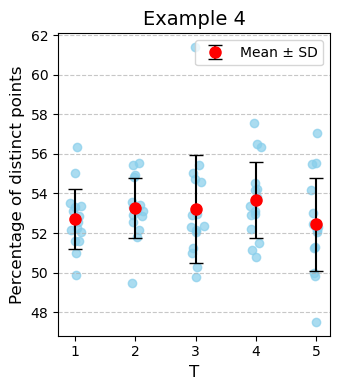

In [15]:
# Compute mean and std for each key
keys = list(res_T.keys())
means = [np.mean(res_T[k]) for k in keys]
stds = [np.std(res_T[k]) for k in keys]

plt.figure(figsize=(3.5,4))

# Plot all points with some horizontal jitter
for i, k in enumerate(keys):
    y = res_T[k]
    x = np.random.normal(loc=i+1, scale=0.05, size=len(y))  # jitter for visibility
    plt.scatter(x, y, color='skyblue', alpha=0.7, label='_nolegend_')

# Overlay mean as a red marker with error bars
plt.errorbar(keys, means, yerr=stds, fmt='o', color='red', ecolor='black', elinewidth=1.5,
             capsize=5, markersize=8, label='Mean ± SD')

# Formatting
plt.xticks(keys)
plt.xlabel('T', fontsize=12)
plt.ylabel('Percentage of distinct points', fontsize=12) # mean PDP across the number of starting points.
plt.title('Example 4', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.savefig("Ex4Tmax.png", dpi=300, bbox_inches="tight")
plt.show()